In [1]:
# Cell 1 — imports and paths
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
 
RESULTS_ROOT = Path("../results_thesis")
LANGS = ["en", "de", "fr", "nl"]
SEEDS = [42, 123, 456]
CMAP = 'Greens' # consistent colormap across all confusion matrices

In [2]:
# Cell 2 — load hard routing data and compute confusion matrix
hard_matrices = []
 
for seed in SEEDS:
    path = RESULTS_ROOT / "moe_hard" / f"seed{seed}" / "routing.json"
    with open(path) as f:
        routing_data = json.load(f)
 
    matrix = np.zeros((4, 4))
    for i, src_lang in enumerate(LANGS):
        entries = routing_data[src_lang]
        for e in entries:
            j = LANGS.index(e["top_expert"])
            matrix[i, j] += 1
        matrix[i] /= matrix[i].sum()
 
    hard_matrices.append(matrix)
 
hard_mean = np.mean(hard_matrices, axis=0) * 100
hard_std  = np.std(hard_matrices,  axis=0) * 100
 
print("Hard routing confusion matrix (%):")
print(np.round(hard_mean, 1))

Hard routing confusion matrix (%):
[[77.6  0.2  1.  21.2]
 [ 6.8 40.1  3.6 49.4]
 [ 4.8  0.9 54.8 39.5]
 [ 4.7  4.6  3.9 86.8]]


In [3]:
print("Per-language accuracy (mean ± std):")
for i, lang in enumerate(LANGS):
    accs = [hard_matrices[s][i, i] * 100 for s in range(3)]
    print(f"  {lang.upper()}: {np.mean(accs):.1f}% ± {np.std(accs):.1f}%")
 
print("\nMajor misrouting (>20%):")
for i in range(4):
    for j in range(4):
        if i != j and hard_mean[i, j] > 20:
            print(f"  {LANGS[i].upper()} → {LANGS[j].upper()}: {hard_mean[i, j]:.1f}%")

Per-language accuracy (mean ± std):
  EN: 77.6% ± 6.5%
  DE: 40.1% ± 5.2%
  FR: 54.8% ± 5.3%
  NL: 86.8% ± 3.4%

Major misrouting (>20%):
  EN → NL: 21.2%
  DE → NL: 49.4%
  FR → NL: 39.5%


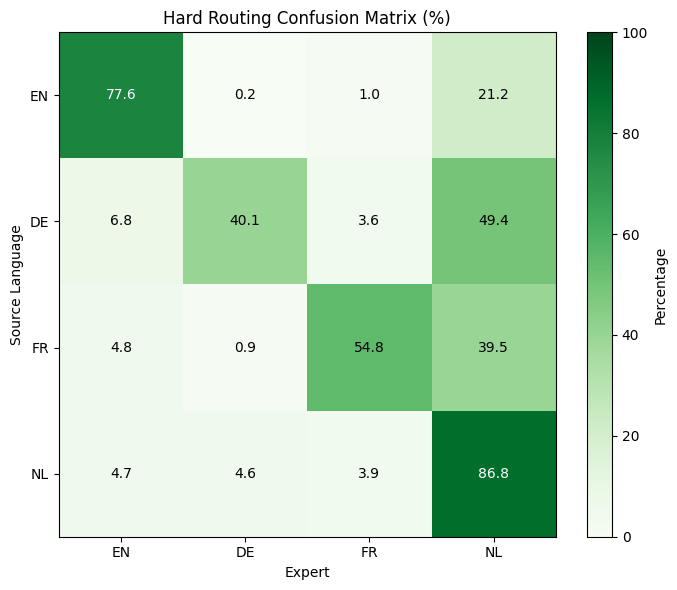

Overall hard routing accuracy: 64.8%


In [4]:
fig, ax = plt.subplots(figsize=(7, 6))
#im = ax.imshow(hard_mean, cmap=CMAP, aspect="auto", vmin=0, vmax=100)
im = ax.imshow(hard_mean, cmap='Greens', aspect='auto', vmin=0, vmax=100)
ax.set_xticks(range(4))
ax.set_yticks(range(4))
ax.set_xticklabels([l.upper() for l in LANGS])
ax.set_yticklabels([l.upper() for l in LANGS])
ax.set_xlabel("Expert")
ax.set_ylabel("Source Language")
ax.set_title("Hard Routing Confusion Matrix (%)")
 
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{hard_mean[i, j]:.1f}", ha="center", va="center", fontsize=10,
                color="white" if hard_mean[i, j] > 60 else "black")
 
plt.colorbar(im, ax=ax, label="Percentage")
plt.tight_layout()
#plt.savefig("hard_routing_confusion.pdf", dpi=150)
plt.show()
 
# %%
# Cell 5 — hard routing overall summary
overall_hard = np.mean([hard_mean[i, i] for i in range(4)])
print(f"Overall hard routing accuracy: {overall_hard:.1f}%")

# Soft

In [5]:
# Cell 6 — load soft routing data
soft_weight_matrices = []
soft_topk_matrices   = []
 
for seed in SEEDS:
    path = RESULTS_ROOT / "moe_soft" / f"seed{seed}" / "routing.json"
    with open(path) as f:
        routing_data = json.load(f)
 
    weight_matrix = np.zeros((4, 4))
    topk_matrix   = np.zeros((4, 4))
 
    for i, src_lang in enumerate(LANGS):
        entries = routing_data[src_lang]
        weights_list = []
        for e in entries:
            w = np.array(e["weights"])
            if w.ndim == 2:
                w = w[0]
            weights_list.append(w)
            topk_matrix[i, int(np.argmax(w))] += 1
        weight_matrix[i] = np.mean(weights_list, axis=0)
        topk_matrix[i] /= topk_matrix[i].sum()
 
    soft_weight_matrices.append(weight_matrix)
    soft_topk_matrices.append(topk_matrix)
 
soft_weight_mean = np.mean(soft_weight_matrices, axis=0)
soft_topk_mean   = np.mean(soft_topk_matrices,   axis=0) * 100
soft_topk_std    = np.std(soft_topk_matrices,    axis=0) * 100
 
print("Soft routing mean weight distribution:")
print("       " + "  ".join(f"w_{l.upper():<4}" for l in LANGS))
for i, lang in enumerate(LANGS):
    print(f"{lang.upper():<6} " + "  ".join(f"{soft_weight_mean[i, j]:.3f}" for j in range(4)))

Soft routing mean weight distribution:
       w_EN    w_DE    w_FR    w_NL  
EN     0.309  0.207  0.199  0.285
DE     0.161  0.362  0.217  0.260
FR     0.150  0.263  0.328  0.260
NL     0.168  0.305  0.240  0.287


In [6]:
# Cell 7 — soft routing statistics
print("Soft routing per-language accuracy (mean ± std):")
for i, lang in enumerate(LANGS):
    accs = [soft_topk_matrices[s][i, i] * 100 for s in range(3)]
    print(f"  {lang.upper()}: {np.mean(accs):.1f}% ± {np.std(accs):.1f}%")
 
print("\nMajor misrouting (>20%):")
for i in range(4):
    for j in range(4):
        if i != j and soft_topk_mean[i, j] > 20:
            print(f"  {LANGS[i].upper()} → {LANGS[j].upper()}: {soft_topk_mean[i, j]:.1f}%")

Soft routing per-language accuracy (mean ± std):
  EN: 71.0% ± 10.8%
  DE: 84.0% ± 3.0%
  FR: 67.1% ± 5.2%
  NL: 36.8% ± 2.2%

Major misrouting (>20%):
  EN → NL: 27.6%
  FR → NL: 22.3%
  NL → DE: 55.7%


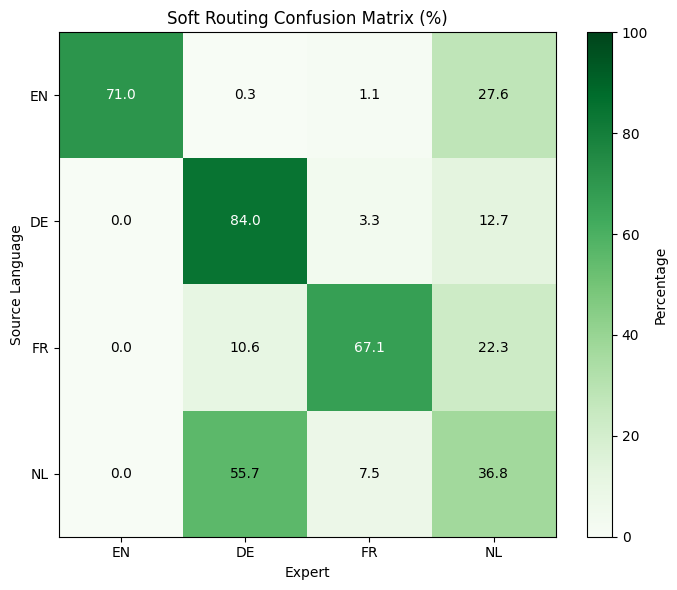

In [7]:
# Cell 8 — soft routing confusion matrix heatmap
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(soft_topk_mean, cmap='Greens', aspect="auto", vmin=0, vmax=100)
 
ax.set_xticks(range(4))
ax.set_yticks(range(4))
ax.set_xticklabels([l.upper() for l in LANGS])
ax.set_yticklabels([l.upper() for l in LANGS])
ax.set_xlabel("Expert")
ax.set_ylabel("Source Language")
ax.set_title("Soft Routing Confusion Matrix (%)")
 
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{soft_topk_mean[i, j]:.1f}", ha="center", va="center", fontsize=10,
                color="white" if soft_topk_mean[i, j] > 60 else "black")
 
plt.colorbar(im, ax=ax, label="Percentage")
plt.tight_layout()
#plt.savefig("soft_routing_confusion.pdf", dpi=150)
plt.show()

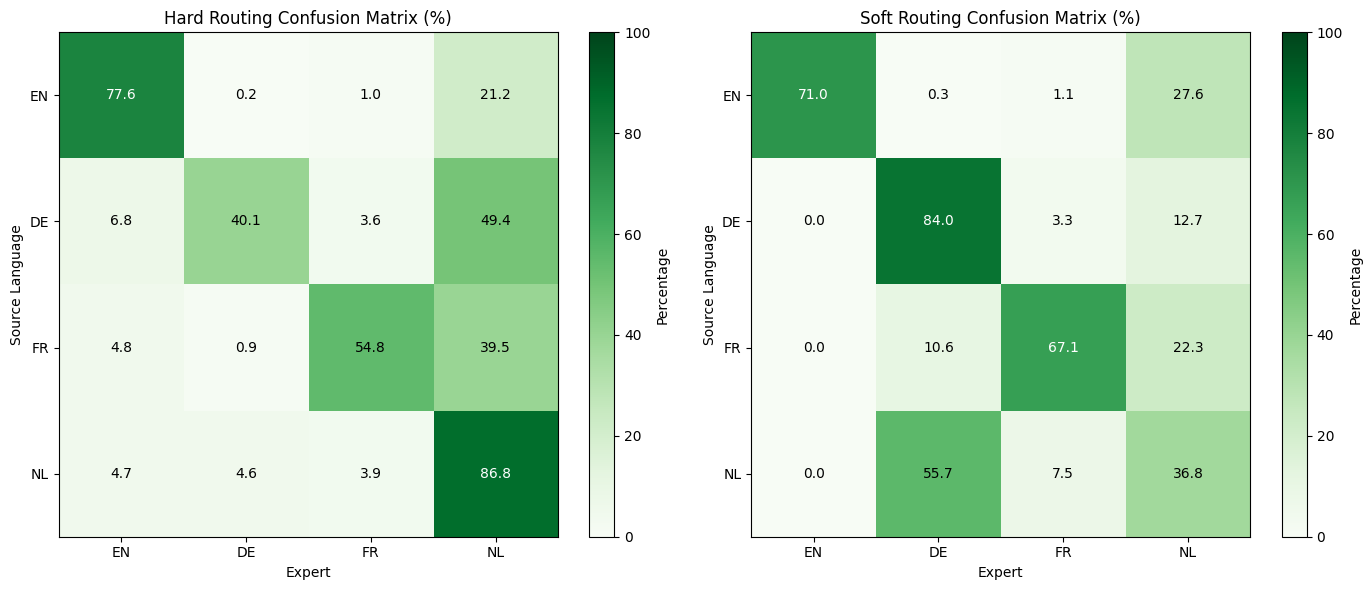

In [8]:
# Cell 9 — side-by-side: hard vs soft
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
for ax, matrix, title in zip(
    axes,
    [hard_mean, soft_topk_mean],
    ["Hard Routing", "Soft Routing"],
):
    im = ax.imshow(matrix, cmap=CMAP, aspect="auto", vmin=0, vmax=100)
    ax.set_xticks(range(4))
    ax.set_yticks(range(4))
    ax.set_xticklabels([l.upper() for l in LANGS])
    ax.set_yticklabels([l.upper() for l in LANGS])
    ax.set_xlabel("Expert")
    ax.set_ylabel("Source Language")
    ax.set_title(f"{title} Confusion Matrix (%)")
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f"{matrix[i, j]:.1f}", ha="center", va="center", fontsize=10,
                    color="white" if matrix[i, j] > 60 else "black")
    plt.colorbar(im, ax=ax, label="Percentage")
 
plt.tight_layout()
#plt.savefig("routing_confusion_comparison.pdf", dpi=150)
plt.show()

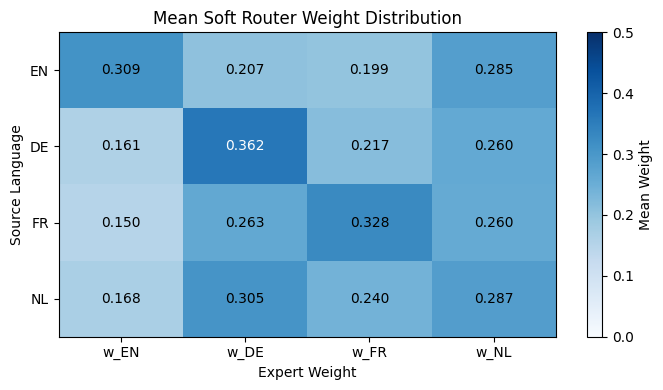

In [9]:
#Cell 10 — soft weight distribution heatmap (Blues, separate scale)
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(soft_weight_mean, cmap="Blues", aspect="auto", vmin=0, vmax=0.5)
 
ax.set_xticks(range(4))
ax.set_yticks(range(4))
ax.set_xticklabels([f"w_{l.upper()}" for l in LANGS])
ax.set_yticklabels([l.upper() for l in LANGS])
ax.set_xlabel("Expert Weight")
ax.set_ylabel("Source Language")
ax.set_title("Mean Soft Router Weight Distribution")
 
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{soft_weight_mean[i, j]:.3f}", ha="center", va="center", fontsize=10,
                color="white" if soft_weight_mean[i, j] > 0.35 else "black")
 
plt.colorbar(im, ax=ax, label="Mean Weight")
plt.tight_layout()
#plt.savefig("soft_weight_distribution.pdf", dpi=150)
plt.show()
 

In [10]:
# Cell 11 — DE/NL routing duality summary
print("DE/NL Routing Duality")
print("=" * 40)
print(f"{'Language':<8} {'Hard':>8} {'Soft':>8} {'Delta':>8}")
print("-" * 36)
for i, lang in enumerate(LANGS):
    h = hard_mean[i, i]
    s = soft_topk_mean[i, i]
    print(f"{lang.upper():<8} {h:>7.1f}% {s:>7.1f}% {s-h:>+7.1f}%")
 
print(f"\nOverall hard: {np.mean([hard_mean[i,i] for i in range(4)]):.1f}%")
print(f"Overall soft: {np.mean([soft_topk_mean[i,i] for i in range(4)]):.1f}%")

DE/NL Routing Duality
Language     Hard     Soft    Delta
------------------------------------
EN          77.6%    71.0%    -6.6%
DE          40.1%    84.0%   +43.9%
FR          54.8%    67.1%   +12.2%
NL          86.8%    36.8%   -50.0%

Overall hard: 64.8%
Overall soft: 64.7%
